Total images ready for training: 376


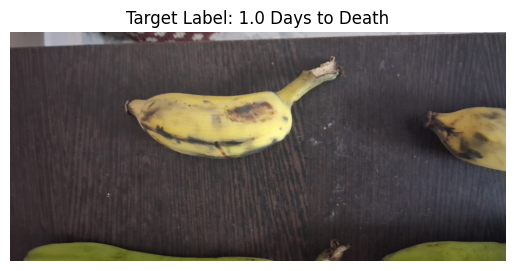

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

# 1. Load the lookup table you built earlier
df = pd.read_csv("banana_labels.csv")
print(f"Total images ready for training: {len(df)}")

# 2. Grab the very first image path from the CSV
base_folder = "./banana_dataset" 
first_image_path = os.path.join(base_folder, df.iloc[0]['image_path'])

# 3. Open and display the original image
img = Image.open(first_image_path)
plt.imshow(img)
plt.title(f"Target Label: {df.iloc[0]['days_to_death']} Days to Death")
plt.axis('off')
plt.show()

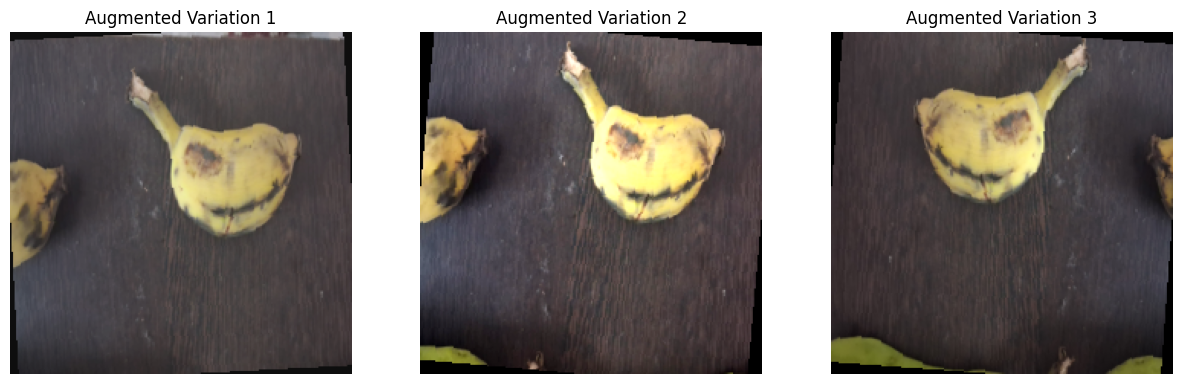

Final Neural Network Tensor Shape: torch.Size([3, 224, 224])


In [3]:
import torch
from torchvision import transforms

# Define the exact same math we put in your dataset.py (minus Normalization)
aug_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),           
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomRotation(degrees=15),  
    transforms.ColorJitter(brightness=0.2, contrast=0.2), 
    transforms.ToTensor()
])

# Generate 3 unique, augmented versions of the same banana
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(3):
    img_tensor = aug_transform(img)
    # PyTorch uses [Color, Height, Width]. Matplotlib needs [Height, Width, Color] to draw.
    img_plot = img_tensor.permute(1, 2, 0) 
    
    axes[i].imshow(img_plot)
    axes[i].set_title(f"Augmented Variation {i+1}")
    axes[i].axis('off')

plt.show()
print(f"Final Neural Network Tensor Shape: {img_tensor.shape}")